# Benchmark model performance

This notebooks benchmarks the available predictive models on sequence data.

In [1]:
import collections
import itertools
import os

import IPython.display as ipy_display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg
import seaborn as sns
from scipy import stats
from sklearn import metrics

In [2]:
TAB = '&nbsp;&nbsp;&nbsp;&nbsp;'

In [3]:
sequences = pd.read_csv('data/interim/sequences_pMHC_split.csv', index_col='index')

In [4]:
predictions = []

for path in (
    'data/processed/TCRStructMap_predictions_on_sequences_pMHC_split.csv',
    'data/processed/TCRStructMap_sequence_only_predictions_on_sequences_pMHC_split.csv',
    'data/processed/NetTCR_predictions_on_sequences_pMHC_split.csv',
):
    model_name = os.path.basename(path).replace('_predictions_on_sequences_pMHC_split.csv', '')
    model_predictions = pd.read_csv(path)
    model_predictions['model_name'] = model_name

    predictions.append(model_predictions)

predictions = pd.concat(predictions).reset_index(drop=True)

predictions = predictions.merge(sequences, how='left', left_on='index', right_index=True)
predictions = predictions[predictions['fold'] == predictions['sub_model_number']].reset_index(drop=True)

In [5]:
af3_scores = pd.read_csv('data/external/confidence_scores_af3_tcrmodel2_1500.csv')
af3_scores['index'] = af3_scores['structure_name']

In [6]:
af3_scores['prediction'] = 1 - (
    (af3_scores['cdr_pmhc_pae_score'] - af3_scores['cdr_pmhc_pae_score'].min())
    / (af3_scores['cdr_pmhc_pae_score'].max() - af3_scores['cdr_pmhc_pae_score'].min())
)

In [7]:
af3_scores = af3_scores.query('top_model')

In [8]:
af3_scores['model_name'] = 'AlphaFold3'

In [9]:
af3_scores = af3_scores[['index', 'model_name', 'prediction']].merge(
    sequences, how='inner', left_on='index', right_index=True
)

In [10]:
combined_predictions = pd.concat([predictions, af3_scores])

In [11]:
combined_predictions = combined_predictions.pivot_table(
    index='index', values='prediction', columns='model_name'
).dropna()

In [12]:
NUM_SAMPLES = 25
SAMPLE_SIZE = 1000

rng = np.random.default_rng(123)

samples = []

for sample_num in range(1, NUM_SAMPLES + 1):
    sample = combined_predictions.sample(SAMPLE_SIZE, random_state=rng)
    sample['sample_num'] = str(sample_num)

    samples.append(sample)

samples = pd.concat(samples)

In [13]:
samples = samples.reset_index()

In [14]:
samples = samples.melt(
    id_vars=['index', 'sample_num'],
    value_vars=[col_name for col_name in samples.columns if col_name != 'sample_num'],
    var_name='model_name',
    value_name='prediction',
)

In [15]:
samples = samples.merge(sequences, how='left', left_on='index', right_index=True)

In [16]:
def model_name_sort_key(name: str) -> tuple[str, str]:
    return (-ord(name[0]), name)

## ROC

In [17]:
roc_results = samples.groupby(['model_name', 'sample_num']).apply(
    lambda group: metrics.roc_curve(group['label'], group['prediction']),
    include_groups=False,
)
roc_results.name = 'roc_curve'
roc_results = roc_results.reset_index()

In [18]:
roc_01_results = samples.groupby(['model_name', 'sample_num']).apply(
    lambda group: metrics.roc_auc_score(group['label'], group['prediction'], max_fpr=0.1),
    include_groups=False,
)
roc_01_results.name = 'roc_auc_01'
roc_01_results = roc_01_results.reset_index()

roc_results = roc_results.merge(roc_01_results, on=['model_name', 'sample_num'], how='inner')

In [19]:
roc_results[['fpr', 'tpr', 'threshold']] = roc_results['roc_curve'].apply(pd.Series)
roc_results['roc_auc'] = roc_results.apply(lambda row: metrics.auc(row['fpr'], row['tpr']), axis=1)

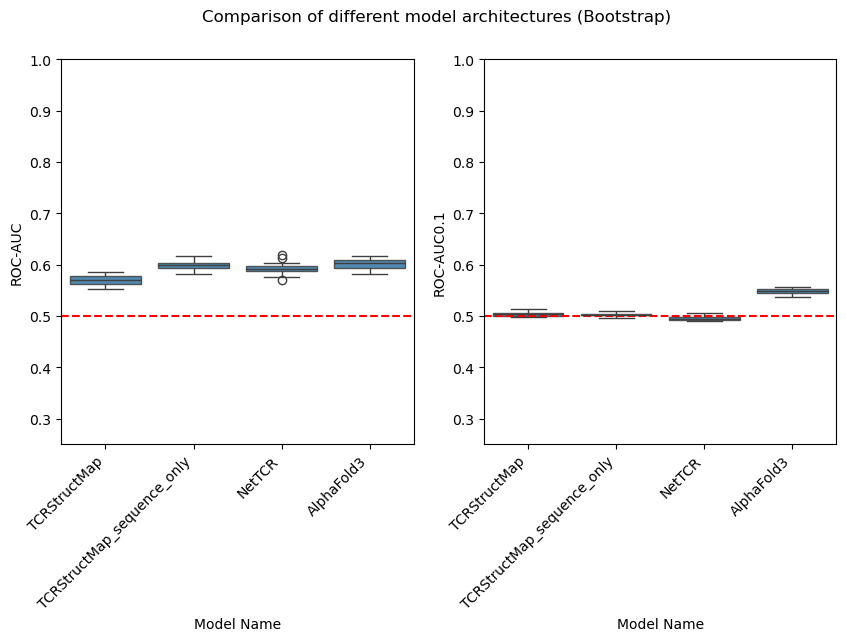

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

plt.suptitle('Comparison of different model architectures (Bootstrap)')

for i, metric_name in enumerate(('roc_auc', 'roc_auc_01')):
    sns.boxplot(
        roc_results,
        x='model_name',
        y=metric_name,
        order=sorted(roc_results['model_name'].unique(), key=model_name_sort_key),
        boxprops={'alpha': 0.85},
        color='C0',
        ax=axes[i],
    )

    axes[i].axhline(0.5, color='r', linestyle='dashed')

    axes[i].set_ylabel({'roc_auc': 'ROC-AUC', 'roc_auc_01': 'ROC-AUC0.1'}[metric_name])
    axes[i].set_xlabel('Model Name')

    axes[i].set_xticks(axes[i].get_xticks())
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')

    axes[i].set_ylim([0.25, 1.0])

plt.show()

In [21]:
for metric_name in ('roc_auc', 'roc_auc_01'):
    print({'roc_auc': 'ROC-AUC', 'roc_auc_01': 'ROC-AUC0.1'}[metric_name])
    ipy_display.display(pg.friedman(roc_results, dv='roc_auc', within='model_name', subject='sample_num'))

    groups = list(roc_results.set_index('sample_num').groupby('model_name')[metric_name])
    groups = sorted(groups, key=lambda group: model_name_sort_key(group[0]))
    groups = [(group_name, group.sort_index()) for group_name, group in groups]

    significance_level = 0.05 / len(groups)

    results = collections.defaultdict(list)
    for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
        stat, p_val = stats.wilcoxon(group1, group2, alternative='greater')

        results['group1'].append(group1_name)
        results['group2'].append(group2_name)
        results['stat'].append(stat)
        results['p_val'].append(p_val)
        results['signficant'].append(p_val < significance_level)

    ipy_display.display(pd.DataFrame(results))
    print()

ROC-AUC


,Source,W,ddof1,Q,p-unc
Friedman,model_name,0.6416,3,48.12,2.007877e-10


,group1,group2,stat,p_val,signficant
0,TCRStructMap,TCRStructMap_sequence_only,0.0,1.000000,False
1,TCRStructMap,NetTCR,0.0,1.000000,False
2,TCRStructMap,AlphaFold3,1.0,1.000000,False
3,TCRStructMap_sequence_only,NetTCR,258.0,0.004411,True
4,TCRStructMap_sequence_only,AlphaFold3,113.0,0.909135,False
5,NetTCR,AlphaFold3,46.0,0.999544,False



ROC-AUC0.1


,Source,W,ddof1,Q,p-unc
Friedman,model_name,0.6416,3,48.12,2.007877e-10


,group1,group2,stat,p_val,signficant
0,TCRStructMap,TCRStructMap_sequence_only,184.0,2.891031e-01,False
1,TCRStructMap,NetTCR,324.0,5.960464e-08,True
2,TCRStructMap,AlphaFold3,0.0,1.000000e+00,False
3,TCRStructMap_sequence_only,NetTCR,322.0,1.490116e-07,True
4,TCRStructMap_sequence_only,AlphaFold3,0.0,1.000000e+00,False
5,NetTCR,AlphaFold3,0.0,1.000000e+00,False


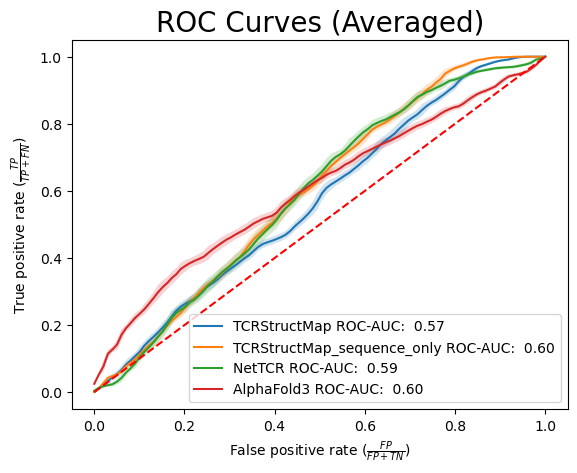

In [22]:
model_groups = roc_results.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=model_name_sort_key)

fpr_interp = np.linspace(0, 1, 100)
tpr_interp = {}

for model_name, model_group in model_groups:
    tpr_interp[model_name] = {}
    for sample_num, sample_group in model_group.groupby('sample_num'):
        group = sample_group.explode(['tpr', 'fpr'])

        tpr_interp[model_name][sample_num] = np.interp(fpr_interp, group['fpr'].apply(float), group['tpr'].apply(float))

for model_name in model_group_names:
    model_group = model_groups.get_group(model_name)

    tpr_mean = np.mean(np.array(list(tpr_interp[model_name].values())).T, axis=1)
    tpr_std = np.std(np.array(list(tpr_interp[model_name].values())).T, axis=1)

    roc_auc = metrics.auc(fpr_interp, tpr_mean)

    plt.plot(fpr_interp, tpr_mean, label=f'{model_name} ROC-AUC: {roc_auc: .2f}')
    plt.fill_between(fpr_interp, tpr_mean - tpr_std, tpr_mean + tpr_std, alpha=0.2)

plt.title('ROC Curves (Averaged)', fontsize=20)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel(r'False positive rate ($\frac{FP}{FP + TN}$)')
plt.ylabel(r'True positive rate ($\frac{TP}{TP + FN}$)')
plt.legend()

plt.show()

In [23]:
roc_results_agg = roc_results.groupby('model_name').agg(
    {'roc_auc': ['mean', 'median', 'std', 'count'], 'roc_auc_01': ['mean', 'median', 'std', 'count']}
)
roc_results_agg = roc_results_agg.loc[sorted(roc_results_agg.index, key=model_name_sort_key)]
roc_results_agg.index.name = roc_results_agg.index.name.title().replace('_', ' ')

std_df = roc_results_agg.xs('std', axis=1, level=1)
count_df = roc_results_agg.xs('count', axis=1, level=1)

stderr_df = std_df / np.sqrt(count_df)
stderr_df.columns = pd.MultiIndex.from_product([stderr_df.columns, ['stderr']])

roc_results_agg = pd.concat([roc_results_agg, stderr_df], axis=1).sort_index(axis=1)
roc_results_agg = roc_results_agg.loc[:, roc_results_agg.columns.get_level_values(1) != 'count']

roc_results_agg_means = roc_results_agg.xs('mean', axis=1, level=1)
roc_results_agg_stderrs = roc_results_agg.xs('stderr', axis=1, level=1)

roc_results_agg = roc_results_agg_means.combine(
    roc_results_agg_stderrs, lambda mean, se: mean.map('{:.2f}'.format) + ' ± ' + se.map('{:.2e}'.format)
)

roc_results_agg = roc_results_agg[['roc_auc', 'roc_auc_01']].rename(
    lambda column_name: (column_name.title().replace('_', ' ').replace('Roc Auc', 'ROC-AUC').replace('01', '0.1')),
    axis='columns',
)
roc_results_agg = roc_results_agg.rename({'TCRStructMap_sequence_only': f'{TAB}↳ Sequence Only'})

roc_results_agg_styler = roc_results_agg.style


def highlight_max(series: pd.Series, ref_vals: pd.Series) -> list[str]:
    is_max = series.index == ref_vals.idxmax()
    return ['font-weight: bold' if v else '' for v in is_max]


for col in roc_results_agg.columns:
    column_name = col.lower().replace(' ', '_').replace('-', '_').replace('.', '')
    roc_results_agg_styler = roc_results_agg_styler.apply(
        highlight_max, ref_vals=roc_results_agg_means[column_name], subset=[col]
    )

roc_results_agg_styler = roc_results_agg_styler.set_table_styles(
    [{'selector': '.row_heading', 'props': [('text-align', 'left')]}]
)

roc_results_agg_styler

,ROC-AUC,ROC-AUC 0.1
Model Name,,
TCRStructMap,0.57 ± 1.74e-03,0.50 ± 9.27e-04
↳ Sequence Only,0.60 ± 1.67e-03,0.50 ± 6.77e-04
NetTCR,0.59 ± 2.17e-03,0.50 ± 7.33e-04
AlphaFold3,0.60 ± 1.91e-03,0.55 ± 1.06e-03


## Precision-Recall

In [24]:
pr_results = samples.groupby(['model_name', 'sample_num']).apply(
    lambda group: metrics.precision_recall_curve(group['label'], group['prediction']),
    include_groups=False,
)
pr_results.name = 'pr_curve'
pr_results = pr_results.reset_index()

In [25]:
pr_results[['precision', 'recall', 'threshold']] = pr_results['pr_curve'].apply(pd.Series)

In [26]:
pr_results['pr_auc'] = pr_results.apply(lambda row: metrics.auc(row['recall'], row['precision']), axis=1)

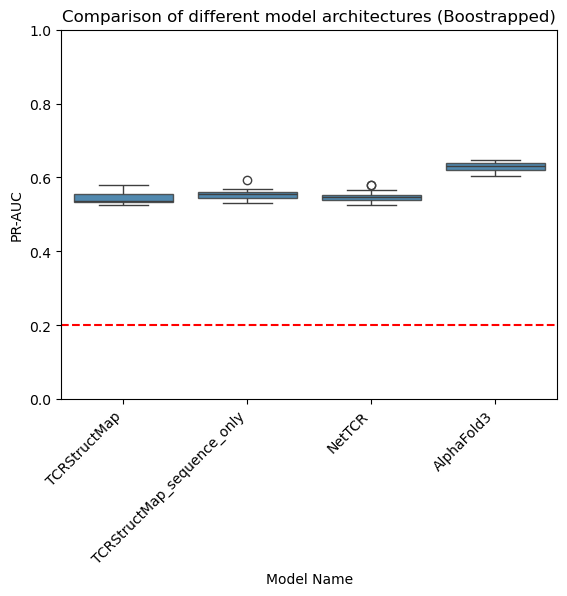

In [27]:
sns.boxplot(
    pr_results,
    x='model_name',
    y='pr_auc',
    order=sorted(pr_results['model_name'], key=model_name_sort_key),
    color='C0',
    boxprops={'alpha': 0.85},
)
plt.axhline(0.2, color='r', linestyle='dashed')

plt.title('Comparison of different model architectures (Boostrapped)')
plt.ylim([0.0, 1.0])
plt.xlabel('Model Name')
plt.ylabel('PR-AUC')
plt.xticks(rotation=45, ha='right')

plt.show()

In [28]:
pg.friedman(pr_results, dv='pr_auc', within='model_name', subject='sample_num')

,Source,W,ddof1,Q,p-unc
Friedman,model_name,0.71008,3,53.256,1.616842e-11


In [29]:
groups = list(pr_results.set_index('sample_num').groupby('model_name')['pr_auc'])
groups = sorted(groups, key=lambda group: model_name_sort_key(group[0]))
groups = [(group_name, group.sort_index()) for group_name, group in groups]

significance_level = 0.05 / len(groups)

results = collections.defaultdict(list)
for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
    stat, p_val = stats.wilcoxon(group1, group2)

    results['group1'].append(group1_name)
    results['group2'].append(group2_name)
    results['stat'].append(stat)
    results['p_val'].append(p_val)
    results['signficant'].append(p_val < significance_level)

pd.DataFrame(results)

,group1,group2,stat,p_val,signficant
0,TCRStructMap,TCRStructMap_sequence_only,15.0,8.165836e-06,True
1,TCRStructMap,NetTCR,90.0,5.157626e-02,False
2,TCRStructMap,AlphaFold3,0.0,5.960464e-08,True
3,TCRStructMap_sequence_only,NetTCR,66.0,8.068800e-03,True
4,TCRStructMap_sequence_only,AlphaFold3,0.0,5.960464e-08,True
5,NetTCR,AlphaFold3,0.0,5.960464e-08,True


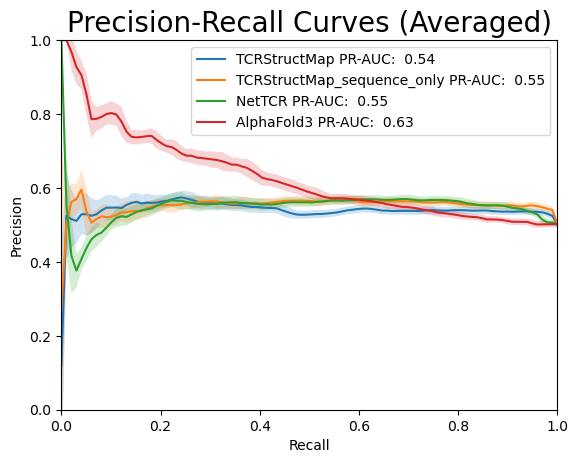

In [30]:
model_groups = pr_results.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=model_name_sort_key)

recall_interp = np.linspace(0, 1, 100)
precision_interp = {}

for model_name, model_group in model_groups:
    precision_interp[model_name] = {}
    for fold, fold_group in model_group.groupby('sample_num'):
        group = fold_group.explode(['recall', 'precision'])

        precision_interp[model_name][fold] = np.interp(
            recall_interp,
            group['recall'].apply(float)[::-1],
            group['precision'].apply(float)[::-1],
        )

for model_name in model_group_names:
    precision_mean = np.mean(np.array(list(precision_interp[model_name].values())).T, axis=1)
    precision_std = np.std(np.array(list(precision_interp[model_name].values())).T, axis=1)

    pr_auc = metrics.auc(recall_interp, precision_mean)

    plt.plot(recall_interp, precision_mean, label=f'{model_name} PR-AUC: {pr_auc: .2f}')
    plt.fill_between(recall_interp, precision_mean - precision_std, precision_mean + precision_std, alpha=0.2)

plt.title('Precision-Recall Curves (Averaged)', fontsize=20)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.legend()

plt.show()

In [31]:
pr_results_agg = pr_results.groupby('model_name').agg({'pr_auc': ['mean', 'median', 'std', 'count']})
pr_results_agg = pr_results_agg.loc[sorted(pr_results_agg.index, key=model_name_sort_key)]
pr_results_agg.index.name = pr_results_agg.index.name.title().replace('_', ' ')

std_df = pr_results_agg.xs('std', axis=1, level=1)
count_df = pr_results_agg.xs('count', axis=1, level=1)

stderr_df = std_df / np.sqrt(count_df)
stderr_df.columns = pd.MultiIndex.from_product([stderr_df.columns, ['stderr']])

pr_results_agg = pd.concat([pr_results_agg, stderr_df], axis=1).sort_index(axis=1)
pr_results_agg = pr_results_agg.loc[:, pr_results_agg.columns.get_level_values(1) != 'count']

pr_results_agg_means = pr_results_agg.xs('mean', axis=1, level=1)
pr_results_agg_stderrs = pr_results_agg.xs('stderr', axis=1, level=1)

pr_results_agg = pr_results_agg_means.combine(
    pr_results_agg_stderrs, lambda mean, se: mean.map('{:.2f}'.format) + ' ± ' + se.map('{:.2e}'.format)
)

pr_results_agg = (
    pr_results_agg[['pr_auc']]
    .rename(
        lambda column_name: (
            column_name.title()
            .replace('_', ' ')
            .replace('Roc Auc', 'ROC-AUC')
            .replace('Pr Auc', 'PR-AUC')
            .replace('01', '0.1')
        ),
        axis='columns',
    )
    .replace('TCRStructMap_sequence_only', 'TCRStructMap (Sequence Only)')
)
pr_results_agg = pr_results_agg.rename({'TCRStructMap_sequence_only': f'{TAB}↳ Sequence Only'})

pr_results_agg_styler = pr_results_agg.style


def highlight_max(series: pd.Series, ref_vals: pd.Series) -> list[str]:
    is_max = series.index == ref_vals.idxmax()
    return ['font-weight: bold' if v else '' for v in is_max]


for col in pr_results_agg.columns:
    column_name = col.lower().replace(' ', '_').replace('-', '_').replace('.', '')
    pr_results_agg_styler = pr_results_agg_styler.apply(
        highlight_max, ref_vals=pr_results_agg_means[column_name], subset=[col]
    )

pr_results_agg_styler = pr_results_agg_styler.set_table_styles(
    [{'selector': '.row_heading', 'props': [('text-align', 'left')]}]
)

pr_results_agg_styler

,PR-AUC
Model Name,
TCRStructMap,0.54 ± 2.85e-03
↳ Sequence Only,0.55 ± 2.46e-03
NetTCR,0.55 ± 2.80e-03
AlphaFold3,0.63 ± 2.31e-03


## F1-Score

In [32]:
THRESHOLD = 0.5
samples['prediction_binary'] = (samples['prediction'] > THRESHOLD).apply(int)

In [33]:
f1_results = samples.groupby(['model_name', 'sample_num']).apply(
    lambda row: metrics.f1_score(row['label'], row['prediction_binary']),
    include_groups=False,
)
f1_results.name = 'f1_score'
f1_results = f1_results.reset_index()

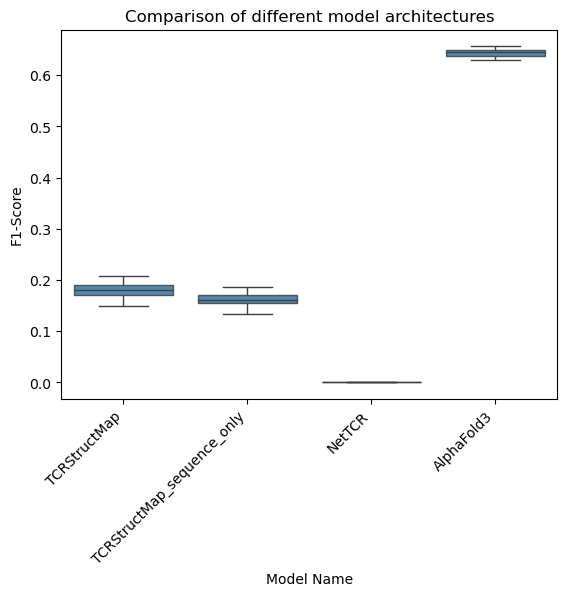

In [34]:
sns.boxplot(
    f1_results,
    x='model_name',
    y='f1_score',
    order=sorted(f1_results['model_name'].unique(), key=model_name_sort_key),
    color='C0',
    boxprops={'alpha': 0.85},
)

plt.title('Comparison of different model architectures')
plt.xlabel('Model Name')
plt.ylabel('F1-Score')
plt.xticks(rotation=45, ha='right')

plt.show()

In [35]:
pg.friedman(f1_results, dv='f1_score', within='model_name', subject='sample_num')

,Source,W,ddof1,Q,p-unc
Friedman,model_name,0.936,3,70.2,3.867513e-15


In [36]:
groups = list(f1_results.set_index('sample_num').groupby('model_name')['f1_score'])
groups = sorted(groups, key=lambda group: model_name_sort_key(group[0]))
groups = [(group_name, group.sort_index()) for group_name, group in groups]

significance_level = 0.05 / len(groups)

results = collections.defaultdict(list)
for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
    stat, p_val = stats.wilcoxon(group1, group2)

    results['group1'].append(group1_name)
    results['group2'].append(group2_name)
    results['stat'].append(stat)
    results['p_val'].append(p_val)
    results['signficant'].append(p_val < significance_level)

pd.DataFrame(results)

,group1,group2,stat,p_val,signficant
0,TCRStructMap,TCRStructMap_sequence_only,27.0,7.498264e-05,True
1,TCRStructMap,NetTCR,0.0,1.227919e-05,True
2,TCRStructMap,AlphaFold3,0.0,5.960464e-08,True
3,TCRStructMap_sequence_only,NetTCR,0.0,1.227919e-05,True
4,TCRStructMap_sequence_only,AlphaFold3,0.0,5.960464e-08,True
5,NetTCR,AlphaFold3,0.0,1.227919e-05,True


In [37]:
f1_results_agg = f1_results.groupby('model_name').agg({'f1_score': ['mean', 'median', 'std', 'count']})

f1_results_agg = f1_results_agg.loc[sorted(f1_results_agg.index, key=model_name_sort_key)]
f1_results_agg.index.name = f1_results_agg.index.name.title().replace('_', ' ')

std_df = f1_results_agg.xs('std', axis=1, level=1)
count_df = f1_results_agg.xs('count', axis=1, level=1)

stderr_df = std_df / np.sqrt(count_df)
stderr_df.columns = pd.MultiIndex.from_product([stderr_df.columns, ['stderr']])

f1_results_agg = pd.concat([f1_results_agg, stderr_df], axis=1).sort_index(axis=1)
f1_results_agg = f1_results_agg.loc[:, f1_results_agg.columns.get_level_values(1) != 'count']

f1_results_agg_means = f1_results_agg.xs('mean', axis=1, level=1)
f1_results_agg_stderrs = f1_results_agg.xs('stderr', axis=1, level=1)

f1_results_agg = f1_results_agg_means.combine(
    f1_results_agg_stderrs, lambda mean, se: mean.map('{:.2f}'.format) + ' ± ' + se.map('{:.2e}'.format)
)

f1_results_agg = f1_results_agg[['f1_score']].rename(
    lambda column_name: (
        column_name.title()
        .replace('_', ' ')
        .replace('Roc Auc', 'ROC-AUC')
        .replace('Pr Auc', 'PR-AUC')
        .replace('F1 Score', 'F1-Score')
        .replace('01', '0.1')
    ),
    axis='columns',
)
f1_results_agg = f1_results_agg.rename({'TCRStructMap_sequence_only': f'{TAB}↳ Sequence Only'})

f1_results_agg_styler = f1_results_agg.style


def highlight_max(series: pd.Series, ref_vals: pd.Series) -> list[str]:
    is_max = series.index == ref_vals.idxmax()
    return ['font-weight: bold' if v else '' for v in is_max]


for col in f1_results_agg.columns:
    column_name = col.lower().replace(' ', '_').replace('-', '_').replace('.', '')
    f1_results_by_fold_agg_styler = f1_results_agg_styler.apply(
        highlight_max, ref_vals=f1_results_agg_means[column_name], subset=[col]
    )

f1_results_agg_styler = f1_results_agg_styler.set_table_styles(
    [{'selector': '.row_heading', 'props': [('text-align', 'left')]}]
)

f1_results_agg_styler

,F1-Score
Model Name,
TCRStructMap,0.18 ± 2.88e-03
↳ Sequence Only,0.16 ± 2.64e-03
NetTCR,0.00 ± 0.00e+00
AlphaFold3,0.64 ± 1.48e-03


## Overall results

In [38]:
results = pd.concat([roc_results_agg, pr_results_agg, f1_results_agg], axis=1)
results_means = pd.concat([roc_results_agg_means, pr_results_agg_means, f1_results_agg_means], axis=1)

styler = results.style
styler = styler.format(precision=2)
styler = styler.set_table_styles([{'selector': '.row_heading', 'props': [('text-align', 'left')]}])


def highlight_max(series: pd.Series, ref_vals: pd.Series) -> list[str]:
    is_max = series.index == ref_vals.idxmax()
    return ['font-weight: bold' if v else '' for v in is_max]


for col in results.columns:
    column_name = col.lower().replace(' ', '_').replace('-', '_').replace('.', '')
    styler = styler.apply(highlight_max, ref_vals=results_means[column_name], subset=[col])

styler

,ROC-AUC,ROC-AUC 0.1,PR-AUC,F1-Score
Model Name,,,,
TCRStructMap,0.57 ± 1.74e-03,0.50 ± 9.27e-04,0.54 ± 2.85e-03,0.18 ± 2.88e-03
↳ Sequence Only,0.60 ± 1.67e-03,0.50 ± 6.77e-04,0.55 ± 2.46e-03,0.16 ± 2.64e-03
NetTCR,0.59 ± 2.17e-03,0.50 ± 7.33e-04,0.55 ± 2.80e-03,0.00 ± 0.00e+00
AlphaFold3,0.60 ± 1.91e-03,0.55 ± 1.06e-03,0.63 ± 2.31e-03,0.64 ± 1.48e-03
